# Assignment 4: Regularization 

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

1. The intuition of adding a penalty is that while ordinary least squares focuses on minimizing error, the penalty discourages the model from using large coefficients and leads to less complexity. This makes sure simpler models are less likely to overfit. 
2. Regularization increases bias through restricting the model, but also reduces variance by reducing the noise in the data. Therefore, this improves the predictive performance.
3. LASSO automatically chooses specific features and sets some coefficients to zero, while Ridge shrinks the coefficients towards zero but keeps all the features. LASSO provides simpler models due to fewer features, while Ridge lessens the influence of the variables. 
4. Variables are scaled through standardization. This is done through subtracting the mean and dividing by the standard deviation. This is done so that variables with larger magnitudes are penalized differently. 
5. The penalty alpha is selected using cross-validation. The value that minimizes the validation error is chosen as the value. 
6. You do not include the penalty term when evaluating the cross-validated MSE, as it will stop the model from initially predicting the new data. The penalty is only used to reduce model complexity.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [30]:
#1 
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression


df = pd.read_csv("./data/cars_hw.csv")
df["Age"] = df["Make_Year"].max() - df["Make_Year"]
X_raw = df[["Mileage_Run", "Age"]]
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X_raw)
scaler = StandardScaler()
X = scaler.fit_transform(X_poly)
y = df["Price"]

In [31]:
#2 
lr = LinearRegression()
lr.fit(X, y)

feature_names = poly.get_feature_names_out(["Mileage_Run", "Age"])
for f, c in zip(feature_names, lr.coef_):
    if f == "Mileage_Run Age":
        print("Interaction coefficient:", c)

Interaction coefficient: -898405.7513563768


In [32]:
#3
from sklearn.linear_model import LassoCV

alphas = np.logspace(1, 3, 20)

lasso = LassoCV(alphas=alphas, cv=20, max_iter=10000)
lasso.fit(X, y)

LassoCV(alphas=array([  10.        ,   12.74274986,   16.23776739,   20.69138081,
         26.36650899,   33.59818286,   42.81332399,   54.55594781,
         69.51927962,   88.58667904,  112.88378917,  143.84498883,
        183.29807108,  233.57214691,  297.63514416,  379.26901907,
        483.29302386,  615.84821107,  784.75997035, 1000.        ]),
        cv=20, max_iter=10000)

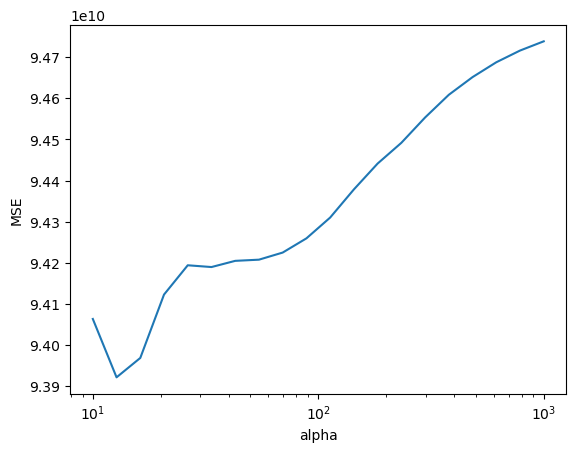

In [33]:
#4
import matplotlib.pyplot as plt
mse = lasso.mse_path_.mean(axis=1)

plt.plot(alphas, mse)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("MSE")
plt.show()

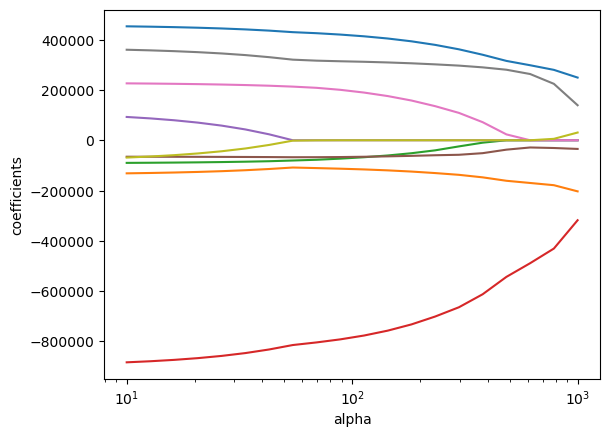

In [34]:
#5
from sklearn.linear_model import Lasso
coefs = []
for a in alphas:
    l = Lasso(alpha=a, max_iter=10000)
    l.fit(X, y)
    coefs.append(l.coef_)
coefs = np.array(coefs)
for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i])
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("coefficients")
plt.show()

In [35]:
#6 
selected = feature_names[lasso.coef_ != 0]
print("Selected features:", selected)
num_zero = np.sum(lasso.coef_ == 0)
prop_zero = num_zero / len(lasso.coef_)
print("Proportion zero:", prop_zero)

Selected features: ['Mileage_Run' 'Age' 'Mileage_Run Age' 'Mileage_Run^3' 'Mileage_Run Age^2'
 'Age^3']
Proportion zero: 0.3333333333333333


In [36]:
#7
print("Linear coefficients:", lr.coef_)
print("LASSO coefficients:", lasso.coef_)

Linear coefficients: [ 458071.11962683 -136698.07209968  -91643.12002368 -898405.75135638
  113603.82234773  -65144.89659917  229021.67655601  368955.71335915
  -84038.06614622]
LASSO coefficients: [ 279901.14447525 -178627.64941809      -0.         -430522.37116681
      -0.          -30772.3523922        0.          224381.02733896
    5666.6268349 ]


**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [37]:
#1 
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

df = pd.read_csv("./data/heart_failure_clinical_records_dataset.csv")
X_cont = df[["age", "ejection_fraction", "serum_creatinine"]]

poly_cont = PolynomialFeatures(degree=3, include_bias=False)
X_cont_poly = poly_cont.fit_transform(X_cont)

scaler = StandardScaler()
X_cont_scaled = scaler.fit_transform(X_cont_poly)
X_bin = df[["anaemia", "diabetes", "high_blood_pressure", "smoking"]]

poly_bin = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_bin_poly = poly_bin.fit_transform(X_bin)
X = np.hstack([X_cont_scaled, X_bin_poly])
y = df["DEATH_EVENT"]

In [38]:
#2 

lr = LinearRegression()
lr.fit(X, y)

print(lr.coef_)

[ 1.53915561 -2.19249366 -0.85358815 -3.67865393 -0.60091803  1.84156257
  3.43097646  2.67339362 -2.64704061  1.99313494  0.90802595 -0.69752151
 -0.08120632 -1.57766526  1.28409929 -1.25034105 -1.27004314  1.17947493
  0.07215578  0.00809253 -0.0707051  -0.00793437 -0.10268659  0.02615948
 -0.02725057  0.06490812  0.13244293  0.15607823  0.10145536]


In [39]:
#3
from sklearn.linear_model import LassoCV

alphas = np.logspace(-5, 5, 30)
lasso = LassoCV(alphas=alphas, cv=20, max_iter=10000)
lasso.fit(X, y)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1.165569925847386, tolerance: 0.0058323943661971875
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 3.019422440365048, tolerance: 0.0058323943661971875
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 7.95487046004296, tolerance: 0.0058323943661971875
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_des

LassoCV(alphas=array([1.00000000e-05, 2.21221629e-05, 4.89390092e-05, 1.08263673e-04,
       2.39502662e-04, 5.29831691e-04, 1.17210230e-03, 2.59294380e-03,
       5.73615251e-03, 1.26896100e-02, 2.80721620e-02, 6.21016942e-02,
       1.37382380e-01, 3.03919538e-01, 6.72335754e-01, 1.48735211e+00,
       3.29034456e+00, 7.27895384e+00, 1.61026203e+01, 3.56224789e+01,
       7.88046282e+01, 1.74332882e+02, 3.85662042e+02, 8.53167852e+02,
       1.88739182e+03, 4.17531894e+03, 9.23670857e+03, 2.04335972e+04,
       4.52035366e+04, 1.00000000e+05]),
        cv=20, max_iter=10000)

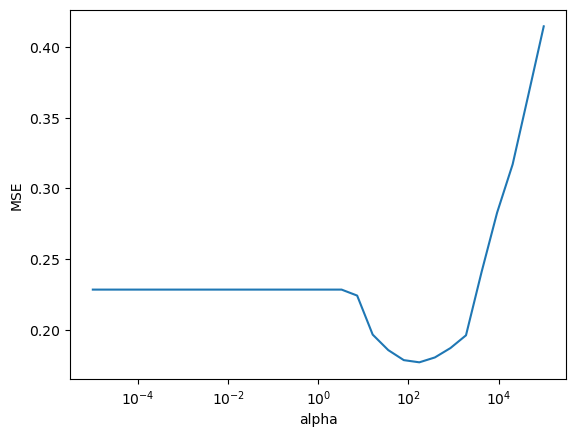

In [40]:
#4 

mse = lasso.mse_path_.mean(axis=1)
plt.plot(alphas, mse)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("MSE")
plt.show()

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.908e+01, tolerance: 6.518e-03
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.666e+01, tolerance: 6.518e-03
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.162e+01, toler

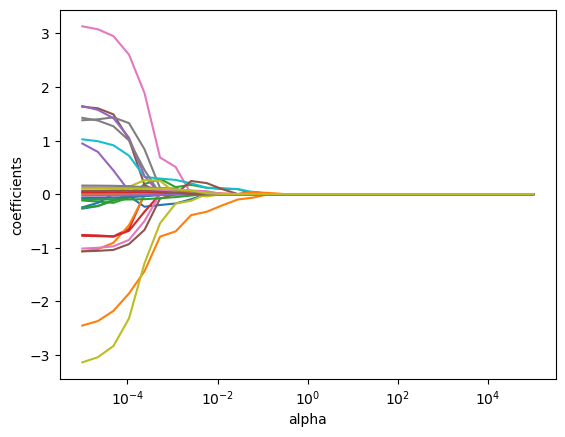

In [41]:
#5 

coefs = []
for a in alphas:
    l = Lasso(alpha=a, max_iter=10000)
    l.fit(X, y)
    coefs.append(l.coef_)

coefs = np.array(coefs)

for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i])

plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("coefficients")
plt.show()

In [42]:
#6 
num_zero = np.sum(lasso.coef_ == 0)
prop_zero = num_zero / len(lasso.coef_)

print("Number of zero coefficients:", num_zero)
print("Proportion zero:", prop_zero)

print("Linear coefficients:", lr.coef_)
print("LASSO coefficients:", lasso.coef_)

'''LASSO sets the variables to zero that are not important and therefore selects a smaller subset of features. The LASSO coefficients then reduce variance and prevents overfitting to improve interpretations.'''


Number of zero coefficients: 17
Proportion zero: 0.5862068965517241
Linear coefficients: [ 1.53915561 -2.19249366 -0.85358815 -3.67865393 -0.60091803  1.84156257
  3.43097646  2.67339362 -2.64704061  1.99313494  0.90802595 -0.69752151
 -0.08120632 -1.57766526  1.28409929 -1.25034105 -1.27004314  1.17947493
  0.07215578  0.00809253 -0.0707051  -0.00793437 -0.10268659  0.02615948
 -0.02725057  0.06490812  0.13244293  0.15607823  0.10145536]
LASSO coefficients: [-0.         -0.32965588  0.11687513  0.         -0.          0.
  0.          0.         -0.          0.1179918   0.          0.
  0.          0.         -0.          0.20482164  0.0328011  -0.
 -0.04326608  0.01417834  0.0006065   0.01360816 -0.          0.
  0.          0.          0.05396847  0.00346643  0.01780528]


'LASSO sets the variables to zero that are not important and therefore selects a smaller subset of features. The LASSO coefficients then reduce variance and prevents overfitting to improve interpretations.'

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

1. The ridge regression objective function is:

$$
\min_{b_0, b_1} \; \frac{1}{n} \sum_{i=1}^{n} (\tilde{y}_i - b_0 - b_1 \tilde{x}_i)^2 + \alpha b_1^2
$$

2. 
$$
b_0 = 0
$$

$$
b_1 = \frac{\sum \tilde{x}_i \tilde{y}_i}{\sum \tilde{x}_i^2 + n\alpha}
$$

3. 
As alpha increases, the denominator increases so therefore b1 shrinks to zero. The slope therefore decreases. 

4.
With the LASSO penalty \( \alpha |b_1| \), when b1 = 0, there exists a sharp edge where a derivative cannot be taken. Instead of simply shrinking the variable, LASSO sets them to zero. The model drops the penalty completely. 